# Analyst Earnings Signal — Multi-Day Residual Aggregation (P days)

Target: **resid(t+1) + resid(t+2) + ... + resid(t+P)**

Set `P = 1` to reproduce the single-day notebook.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

pd.set_option("display.max_columns", 100)

# ── Key parameter ──────────────────────────────────────────────────────────────
P = 3   # holding period: target = resid(t+1) + ... + resid(t+P)


In [15]:
characteristics = pd.read_parquet("Data/Statistical_loadings/characteristics_gamma_1.parquet")
factors = pd.read_parquet("Data/Statistical_loadings/factors_gamma_1.parquet")
residuals = pd.read_parquet("Data/Statistical_loadings/residuals_gamma_1.parquet")
total_returns = pd.read_hdf("Data/daily_returns_SPX.h5")

In [16]:
analyst_data = pd.read_csv("Data/firm_level.csv")
analyst_data["actual_release_date"] = pd.to_datetime(analyst_data["actual_release_date"])
release_dates = analyst_data["actual_release_date"].unique()
common_dates = np.sort(np.array(list(set(residuals.index) & set(release_dates))))
# print(common_dates.shape, residuals.shape[0])
# analyst_data.head()
analyst_tickers = np.sort(analyst_data["ticker"].unique())
resid_tickers = np.array(list(residuals.columns))
common_tickers = np.sort(np.array(list(set(analyst_tickers) & set(resid_tickers))))
resids = residuals[common_tickers]
analysts = analyst_data[analyst_data["ticker"].isin(common_tickers)]
analysts = analysts.drop(columns= ["cwiq_code","fiscal_year.1","fiscal_quarter.1","ticker.1","eps_mad","rev_mad"])
# analysts = analysts.set_index("actual_release_date")

In [17]:
import pandas_market_calendars as mcal

calendars = mcal.get_calendar("NYSE")
business_days = calendars.schedule(start_date = '2019-05-14', end_date = '2026-03-06')
analysts = analysts[analysts["actual_release_date"].isin(business_days.index)]
analysts1 = analysts.set_index(["actual_release_date","ticker"])
analysts1 = analysts1.sort_index(level = 0)

In [18]:
resid_dates_sorted = pd.DatetimeIndex(resids.index.sort_values())
resids_stacked = resids.stack()
resids_stacked.index = resids_stacked.index.set_names(["date", "ticker"])

df = analysts.reset_index()
resid_release = resids.stack().rename("resid_release_date")
resid_release.index = resid_release.index.set_names(["actual_release_date", "ticker"])
df = df.join(resid_release, on=["actual_release_date", "ticker"])

# For each announcement, sum residuals over the next P trading days
positions = resid_dates_sorted.searchsorted(df["actual_release_date"].values, side="right")

target_components = []
valid_mask = np.ones(len(df), dtype=bool)

for k in range(P):
    pos_k = positions + k
    in_bounds_k = pos_k < len(resid_dates_sorted)
    valid_mask &= in_bounds_k

    resid_k_vals = np.full(len(df), np.nan)
    if in_bounds_k.any():
        valid_dates   = resid_dates_sorted[pos_k[in_bounds_k]]
        valid_tickers = df["ticker"].values[in_bounds_k]
        idx_valid = pd.MultiIndex.from_arrays([valid_dates, valid_tickers])
        resid_k_vals[in_bounds_k] = resids_stacked.reindex(idx_valid).values
    target_components.append(resid_k_vals)

target_stack = np.vstack(target_components)          # (P, n_rows)
target_sum   = np.nansum(target_stack, axis=0)
any_nan      = np.any(np.isnan(target_stack), axis=0)
df[f"resid_next_{P}d"] = np.where(valid_mask & ~any_nan, target_sum, np.nan)

df = df.dropna(subset=["resid_release_date", f"resid_next_{P}d"])
analysts1 = df.set_index(["actual_release_date", "ticker"]).sort_index(level=0)
print(f"P={P}: {analysts1.shape[0]} events with complete {P}-day residual window")
analysts1[["resid_release_date", f"resid_next_{P}d"]].head(8)


P=3: 5048 events with complete 3-day residual window


resid_release_date  resid_next_3d
actual_release_date ticker                                   
2019-05-15          CSCO              0.001195       0.067312
2019-05-16          AMAT              0.014842       0.030877
                    NVDA              0.004895       0.012413
2019-05-17          DE               -0.054096       0.041467
2019-05-20          NDSN             -0.024130       0.000345
2019-05-21          AZO               0.048397       0.031554
                    HD               -0.010344       0.032839
                    TJX              -0.003688      -0.012432

In [19]:

analysts1["eps_surprise"] = analysts1["reported_eps"] - analysts1["eps_median"]

analysts1["eps_relative_surprise"] = (
    analysts1["eps_surprise"] / analysts1["eps_median"].abs()
).replace([np.inf, -np.inf], np.nan)

# Surprise normalized by analyst dispersion (SUE-style z-score)
analysts1["eps_sue"] = (
    analysts1["eps_surprise"] / analysts1["eps_std"]
).replace([np.inf, -np.inf], np.nan)

# Analyst disagreement as coefficient of variation
analysts1["eps_dispersion"] = (
    analysts1["eps_std"] / analysts1["eps_mean"].abs()
).replace([np.inf, -np.inf], np.nan)

# --- Revenue features ---
analysts1["rev_surprise"] = analysts1["reported_revenue"] - analysts1["rev_mean"]

analysts1["rev_relative_surprise"] = (
    analysts1["rev_surprise"] / analysts1["rev_mean"].abs()
).replace([np.inf, -np.inf], np.nan)

analysts1["rev_sue"] = (
    analysts1["rev_surprise"] / analysts1["rev_std"]
).replace([np.inf, -np.inf], np.nan)

analysts1["rev_dispersion"] = (
    analysts1["rev_std"] / analysts1["rev_mean"].abs()
).replace([np.inf, -np.inf], np.nan)

# --- Price / intraday features ---
# Intraday return on the release date (after vs before announcement price)
analysts1["intraday_return"] = (
    analysts1["price_after_announcement"] / analysts1["price_before_announcement"] - 1
)

# Residual return on release date already captured in resid_release_date

# --- Volume feature ---
analysts1["volume_ratio"] = (
    analysts1["Trading Volume After Announcement"]
    / analysts1["Trading Volume Before Announcement"]
).replace([np.inf, -np.inf], np.nan)

new_features = ["eps_surprise", "eps_relative_surprise", "eps_sue", "eps_dispersion",
           "rev_surprise", "rev_relative_surprise", "rev_sue", "rev_dispersion",
           "intraday_return", "volume_ratio", "resid_release_date", f"resid_next_{P}d"] 
analysts1[new_features].head(10)

eps_surprise  eps_relative_surprise   eps_sue  \
actual_release_date ticker                                                  
2019-05-15          CSCO          0.0000               0.000000  0.000000   
2019-05-16          AMAT          0.0100               0.014493  0.062914   
                    NVDA         -0.0575              -0.264368 -0.609876   
2019-05-17          DE           -0.0300              -0.008451 -0.200645   
2019-05-20          NDSN         -0.0500              -0.031447 -1.105815   
2019-05-21          AZO           0.7650               0.050246  1.387353   
                    HD            0.0500               0.022523  0.801349   
                    TJX           0.0000               0.000000  0.000000   
2019-05-22          ADI           0.0400               0.030303  1.322407   
                    CPRT          0.0400               0.064516  6.047432   

                            eps_dispersion  rev_surprise  \
actual_release_date ticker                                 
2019-05-15          CSCO          0.027139    113.007721   
2019-05-16          AMAT          0.206797    -93.046154   
                    NVDA          0.369258   -322.571895   
2019-05-17          DE            0.041921   1117.592593   
2019-05-20          NDSN          0.028617     -6.977667   
2019-05-21          AZO           0.035907     22.300000   
                    HD            0.028076    -14.762500   
                    TJX           0.082975    -47.611111   
2019-05-22          ADI           0.022870      3.434783   
                    CPRT          0.010712     13.361000   

                            rev_relative_surprise   rev_sue  rev_dispersion  \
actual_release_date ticker                                                    
2019-05-15          CSCO                 0.008798  0.101877        0.086357   
2019-05-16          AMAT                -0.025618 -0.270357        0.094756   
                    NVDA                -0.126868 -0.152136        0.833916   
2019-05-17          DE                   0.109306  4.438094        0.024629   
2019-05-20          NDSN                -0.012503 -2.196696        0.005692   
2019-05-21          AZO                  0.008078  0.734726        0.010994   
                    HD                  -0.000559 -0.059040        0.009473   
                    TJX                 -0.005105 -0.247564        0.020623   
2019-05-22          ADI                  0.002254  0.150076        0.015022   
                    CPRT                 0.024754  2.116924        0.011693   

                            intraday_return  volume_ratio  resid_release_date  \
actual_release_date ticker                                                      
2019-05-15          CSCO          -0.004421      1.200128            0.001195   
2019-05-16          AMAT          -0.004819      0.990167            0.014842   
                    NVDA          -0.000877      1.554961            0.004895   
2019-05-17          DE            -0.037000      2.701842           -0.054096   
2019-05-20          NDSN          -0.013606      2.070583           -0.024130   
2019-05-21          AZO            0.028701      1.632653            0.048397   
                    HD             0.023797      1.788895           -0.010344   
                    TJX           -0.004300      1.259620           -0.003688   
2019-05-22          ADI            0.026305      1.118728            0.024386   
                    CPRT           0.004246      1.543800           -0.014350   

                            resid_next_3d  
actual_release_date ticker                 
2019-05-15          CSCO         0.067312  
2019-05-16          AMAT         0.030877  
                    NVDA         0.012413  
2019-05-17          DE           0.041467  
2019-05-20          NDSN         0.000345  
2019-05-21          AZO          0.031554  
                    HD           0.032839  
                    TJX         -0.012432  
2019-05-22          

In [20]:
print(analysts1[new_features].corr()[f"resid_next_{P}d"].iloc[:-1])
corr_mat = analysts1[new_features].corr()
corr_mat[corr_mat > 0.05]

eps_surprise             0.067250
eps_relative_surprise    0.026088
eps_sue                  0.005383
eps_dispersion           0.012573
rev_surprise             0.057142
rev_relative_surprise    0.070372
rev_sue                  0.037676
rev_dispersion           0.009393
intraday_return          0.012872
volume_ratio            -0.043103
resid_release_date       0.025974
Name: resid_next_3d, dtype: float64


,eps_surprise,eps_relative_surprise,eps_sue,eps_dispersion,rev_surprise,rev_relative_surprise,rev_sue,rev_dispersion,intraday_return,volume_ratio,resid_release_date,resid_next_3d
eps_surprise,1.000000,0.323426,NaN,NaN,NaN,0.188788,0.076784,NaN,NaN,NaN,0.138689,0.067250
eps_relative_surprise,0.323426,1.000000,NaN,NaN,NaN,0.084136,NaN,NaN,NaN,NaN,0.064288,NaN
eps_sue,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
eps_dispersion,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rev_surprise,NaN,NaN,NaN,NaN,1.000000,0.105357,NaN,NaN,NaN,NaN,NaN,0.057142
rev_relative_surprise,0.188788,0.084136,NaN,NaN,0.105357,1.000000,0.144968,NaN,NaN,NaN,0.072531,0.070372
rev_sue,0.076784,NaN,NaN,NaN,NaN,0.144968,1.000000,NaN,NaN,NaN,NaN,NaN
rev_dispersion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
intraday_return,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.559607,NaN
volume_ratio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN


In [21]:
import statsmodels.api as sm

regression_features = ["eps_surprise"]
analysts1_ = analysts1.dropna(subset=regression_features)
X, y = analysts1_[regression_features], analysts1_[f"resid_next_{P}d"]
X = sm.add_constant(X)
n = int(X.shape[0] * 0.66)
X_train, X_test = X.iloc[:n], X.iloc[n:]
y_train, y_test = y.iloc[:n], y.iloc[n:]
ols = sm.OLS(endog=y_train, exog=X_train).fit()
print(ols.summary())

oos_r2 = 1 - np.mean((y_test - ols.predict(X_test))**2) / np.var(y_test)
print(f"\nOOS R² (P={P}): {oos_r2:.4%}")


                            OLS Regression Results                            
Dep. Variable:          resid_next_3d   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     9.854
Date:                Thu, 04 Jun 2026   Prob (F-statistic):            0.00171
Time:                        21:26:59   Log-Likelihood:                 5666.2
No. Observations:                3331   AIC:                        -1.133e+04
Df Residuals:                    3329   BIC:                        -1.132e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0001      0.001      0.178   

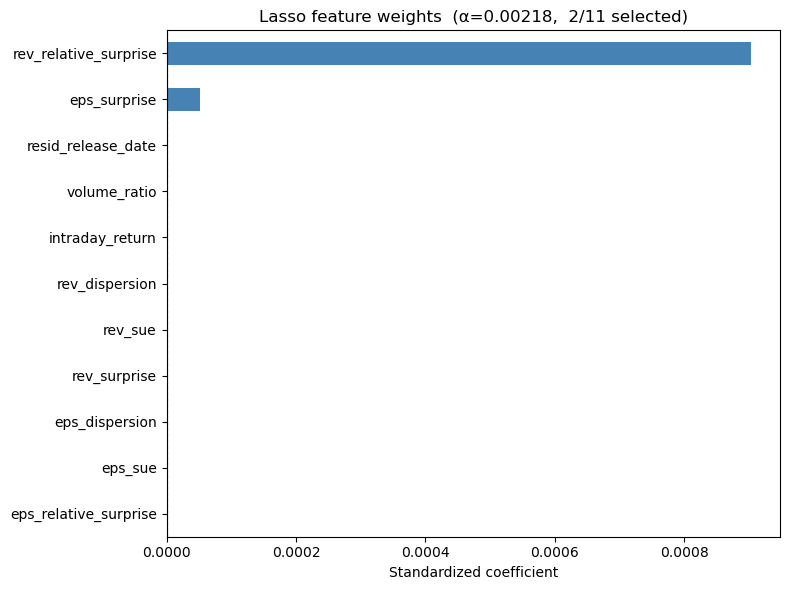

eps_surprise             0.000052
rev_relative_surprise    0.000903
dtype: float64
0.0010588564127642641


In [22]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

lasso_features = new_features[:-1]

analysts1_lasso = analysts1.dropna(subset=lasso_features + [f"resid_next_{P}d"]).sort_index(level=0)
X_l = analysts1_lasso[lasso_features].values
y_l = analysts1_lasso[f"resid_next_{P}d"].values

n_l = int(len(X_l) * 0.66)
X_l_train, y_l_train = X_l[:n_l], y_l[:n_l]
X_l_test, y_l_test = X_l[n_l:], y_l[n_l:]

scaler = StandardScaler()
X_l_train_sc = scaler.fit_transform(X_l_train)

dates = analysts1_lasso.iloc[:n_l,:].index.get_level_values("actual_release_date")
unique_dates = np.sort(dates.unique())
date_tscv = TimeSeriesSplit(n_splits=5)
date_fold_indices = []

for train_dates_idx, test_dates_idx in date_tscv.split(unique_dates):
    train_dates = set(unique_dates[train_dates_idx])
    test_dates  = set(unique_dates[test_dates_idx])
    train_mask = dates.isin(train_dates)
    test_mask  = dates.isin(test_dates)
    date_fold_indices.append((np.where(train_mask)[0], np.where(test_mask)[0]))

lasso = LassoCV(cv=date_fold_indices, max_iter=10000, random_state=42)
lasso.fit(X_l_train_sc, y_l_train)

coefs = pd.Series(lasso.coef_, index=lasso_features).sort_values()
colors = ["steelblue" if c > 0 else "tomato" for c in coefs]

fig, ax = plt.subplots(figsize=(8, 6))
coefs.plot(kind="barh", color=colors, ax=ax)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title(f"Lasso feature weights  (α={lasso.alpha_:.5f},  {(coefs != 0).sum()}/{len(lasso_features)} selected)")
ax.set_xlabel("Standardized coefficient")
plt.tight_layout()
plt.show()

print(coefs[coefs != 0].sort_values())
lasso_oos_r_squared = 1 - np.mean((y_l_test - lasso.predict(scaler.transform(X_l_test)))**2) / np.var(y_l_test)
print(lasso_oos_r_squared)

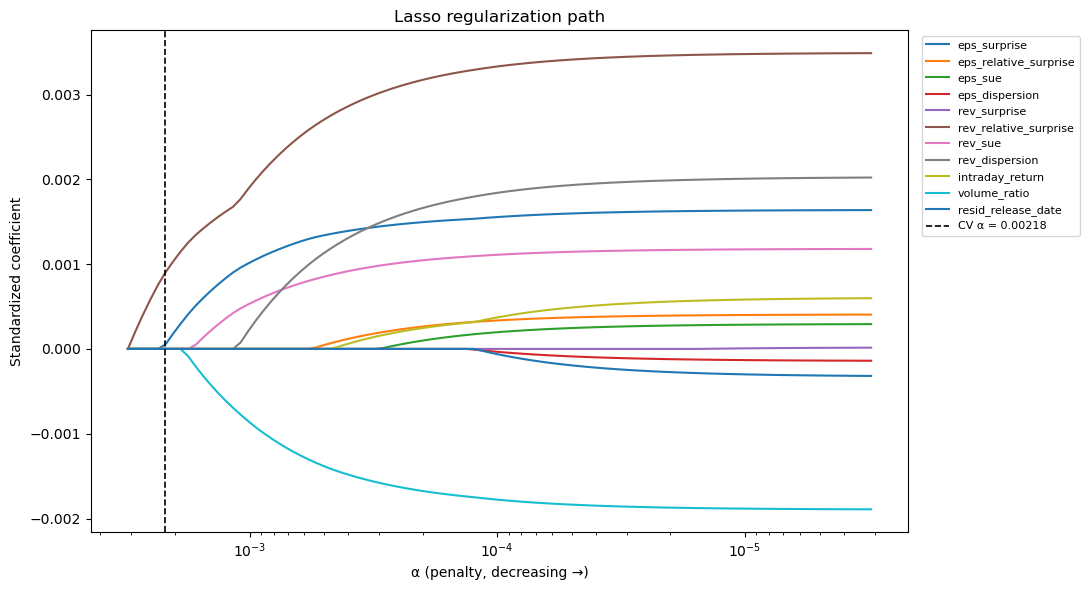

In [23]:
from sklearn.linear_model import lasso_path

alphas, coefs_path, _ = lasso_path(X_l_train_sc, y_l_train, max_iter=10000)

fig, ax = plt.subplots(figsize=(11, 6))
for i, feat in enumerate(lasso_features):
    ax.plot(alphas, coefs_path[i], label=feat)

ax.axvline(lasso.alpha_, color="black", linestyle="--", linewidth=1.2, label=f"CV α = {lasso.alpha_:.5f}")
ax.invert_xaxis()  # high penalty (all-zero) on left → low penalty (all-in) on right
ax.set_xscale("log")
ax.set_xlabel("α (penalty, decreasing →)")
ax.set_ylabel("Standardized coefficient")
ax.set_title("Lasso regularization path")
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

LightGBM OOS R²: 2.1965%  (best iteration: 11)
Lasso    OOS R²: 0.1059%


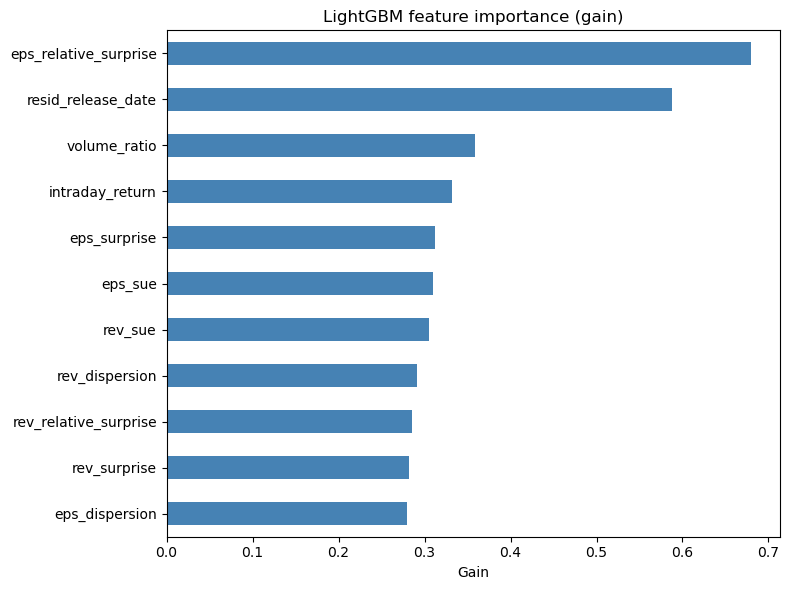

In [27]:
import lightgbm as lgb

# LGBM is tree-based — no scaling needed, use raw features
# Carve last 15% of train as validation for early stopping
val_size = int(len(X_l_train) * 0.15)
X_tr,  X_val  = X_l_train[:-val_size], X_l_train[-val_size:]
y_tr,  y_val  = y_l_train[:-val_size], y_l_train[-val_size:]

lgb_train = lgb.Dataset(X_tr,  label=y_tr,  feature_name=lasso_features)
lgb_val   = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

params = {
    "objective":      "regression",
    "metric":         "mse",
    "learning_rate":  0.05,
    "num_leaves":     31,
    "min_data_in_leaf": 50,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq":   5,
    "verbose":        -1,
}

callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
lgb_model = lgb.train(params, lgb_train, num_boost_round=500,
                      valid_sets=[lgb_val], callbacks=callbacks)

y_pred_lgb = lgb_model.predict(X_l_test)
lgb_oos_r2 = 1 - np.mean((y_l_test - y_pred_lgb)**2) / np.var(y_l_test)
print(f"LightGBM OOS R²: {lgb_oos_r2:.4%}  (best iteration: {lgb_model.best_iteration})")
print(f"Lasso    OOS R²: {lasso_oos_r_squared:.4%}")

# Feature importance by gain
importances = pd.Series(
    lgb_model.feature_importance(importance_type="gain"), index=lasso_features
).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind="barh", color="steelblue", ax=ax)
ax.set_title("LightGBM feature importance (gain)")
ax.set_xlabel("Gain")
plt.tight_layout()
plt.show()

In [25]:
# Date-boundary walk-forward — no date ever straddles a fold boundary
dates_all = analysts1_lasso.index.get_level_values("actual_release_date")
unique_dates = np.sort(dates_all.unique())

date_tscv = TimeSeriesSplit(n_splits=5, test_size=60)  # ~60 unique release dates per test fold
r2_folds_dates = []
ic_folds_dates = []

for train_dates_idx, test_dates_idx in date_tscv.split(unique_dates):
    train_dates = set(unique_dates[train_dates_idx])
    test_dates  = set(unique_dates[test_dates_idx])

    train_mask = dates_all.isin(train_dates)
    test_mask  = dates_all.isin(test_dates)

    X_tr_f, y_tr_f = X_l[train_mask], y_l[train_mask]
    X_te_f, y_te_f = X_l[test_mask],  y_l[test_mask]

    val_n = int(len(X_tr_f) * 0.15)
    ds_tr  = lgb.Dataset(X_tr_f[:-val_n], y_tr_f[:-val_n], feature_name=lasso_features)
    ds_val = lgb.Dataset(X_tr_f[-val_n:],  y_tr_f[-val_n:],  reference=ds_tr)

    m = lgb.train(params, ds_tr, num_boost_round=500, valid_sets=[ds_val],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

    r2 = 1 - np.mean((y_te_f - m.predict(X_te_f))**2) / np.var(y_te_f)
    ic = np.corrcoef(y_te_f,m.predict(X_te_f))[0,1]
    r2_folds_dates.append(r2)
    ic_folds_dates.append(ic)
    print(f"OOS R²: {r2:.4%}, IC = {ic:.4%}  (n_train={train_mask.sum()}, n_test={test_mask.sum()}, best_iter={m.best_iteration})")

print(f"\n OOS R² Mean: {np.mean(r2_folds_dates):.4%}  Std:{np.std(r2_folds_dates):.4%}")
print(f"\n OOS IC Mean: {np.mean(ic_folds_dates):.4%}  Std:{np.std(ic_folds_dates):.4%}")

OOS R²: -0.1345%, IC = 5.3056%  (n_train=2320, n_test=474, best_iter=11)
OOS R²: 0.0530%, IC = 9.2601%  (n_train=2794, n_test=666, best_iter=20)
OOS R²: 2.5989%, IC = 22.8112%  (n_train=3460, n_test=376, best_iter=10)
OOS R²: 4.6443%, IC = 23.2331%  (n_train=3836, n_test=623, best_iter=25)
OOS R²: 2.4867%, IC = 18.3361%  (n_train=4459, n_test=394, best_iter=33)

 OOS R² Mean: 1.9297%  Std:1.7838%

 OOS IC Mean: 15.7892%  Std:7.2628%


Overall Spearman IC : 0.1108  (p=2.27e-08)
Monthly IC mean     : 0.1397  ±0.1730
ICIR                : 0.8075
% months IC > 0     : 82.6%


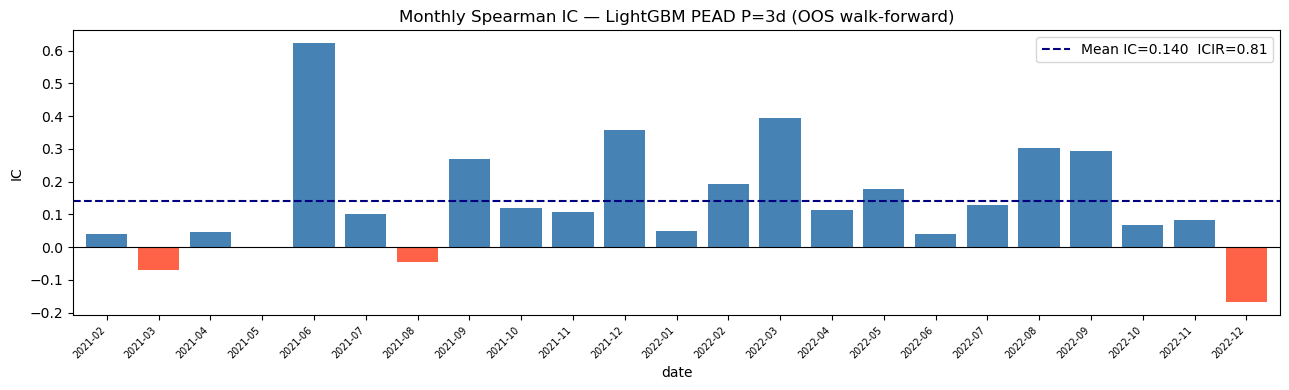

In [28]:
from scipy.stats import spearmanr

# Re-run date-boundary walk-forward collecting all OOS predictions

all_dates, all_preds, all_actual = [], [], []

for train_dates_idx, test_dates_idx in date_tscv.split(unique_dates):
    train_mask = dates_all.isin(set(unique_dates[train_dates_idx]))
    test_mask  = dates_all.isin(set(unique_dates[test_dates_idx]))

    X_tr_f, y_tr_f = X_l[train_mask], y_l[train_mask]
    X_te_f, y_te_f = X_l[test_mask],  y_l[test_mask]

    val_n = int(len(X_tr_f) * 0.15)
    ds_tr  = lgb.Dataset(X_tr_f[:-val_n], y_tr_f[:-val_n], feature_name=lasso_features)
    ds_val = lgb.Dataset(X_tr_f[-val_n:],  y_tr_f[-val_n:],  reference=ds_tr)
    m = lgb.train(params, ds_tr, num_boost_round=500, valid_sets=[ds_val],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

    all_preds.append(m.predict(X_te_f))
    all_actual.append(y_te_f)
    all_dates.append(dates_all[test_mask].values)

preds  = np.concatenate(all_preds)
actual = np.concatenate(all_actual)
dates_oos = np.concatenate(all_dates)

# Overall Spearman IC
ic_overall, p_val = spearmanr(preds, actual)
print(f"Overall Spearman IC : {ic_overall:.4f}  (p={p_val:.2e})")

# Monthly IC and ICIR
oos_df = pd.DataFrame({"date": pd.to_datetime(dates_oos), "pred": preds, "actual": actual})
monthly_ic = (oos_df.groupby(oos_df["date"].dt.to_period("M"))
                    .apply(lambda g: spearmanr(g["pred"], g["actual"])[0] if len(g) > 2 else np.nan)
                    .dropna())

icir = monthly_ic.mean() / monthly_ic.std()
print(f"Monthly IC mean     : {monthly_ic.mean():.4f}  ±{monthly_ic.std():.4f}")
print(f"ICIR                : {icir:.4f}")
print(f"% months IC > 0     : {(monthly_ic > 0).mean():.1%}")

fig, ax = plt.subplots(figsize=(13, 4))
colors = ["steelblue" if v > 0 else "tomato" for v in monthly_ic]
monthly_ic.plot(kind="bar", ax=ax, color=colors, width=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(monthly_ic.mean(), color="navy", linewidth=1.5, linestyle="--",
           label=f"Mean IC={monthly_ic.mean():.3f}  ICIR={icir:.2f}")
ax.set_title(f"Monthly Spearman IC — LightGBM PEAD P={P}d (OOS walk-forward)")
ax.set_ylabel("IC")
ax.legend()
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.show()